<div class="alert alert-danger" role="alert">
<h1 align="center"><font size = 14>Deep-Learning (Part4-CNN)</font></h1>
<h4 align="center">Aug, 11_2026<h4>
<h3 align="center">Armin Amani</h3>

<div class="alert alert-danger" role="alert">
📤 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from sklearn.metrics import classification_report

<div class="alert alert-danger" role="alert"> 
💾 Read Data

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

In [3]:
print(f"shape of training features is : {train_images.shape}")
print(f"shape of training labels is : {train_labels.shape}")
print(f"shape of testing features is : {test_images.shape}")
print(f"shape of testing labels is : {test_labels.shape}")

shape of training features is : (50000, 32, 32, 3)
shape of training labels is : (50000, 1)
shape of testing features is : (10000, 32, 32, 3)
shape of testing labels is : (10000, 1)


<div class="alert alert-danger" role="alert"> 
🔎 Visualization

In [4]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

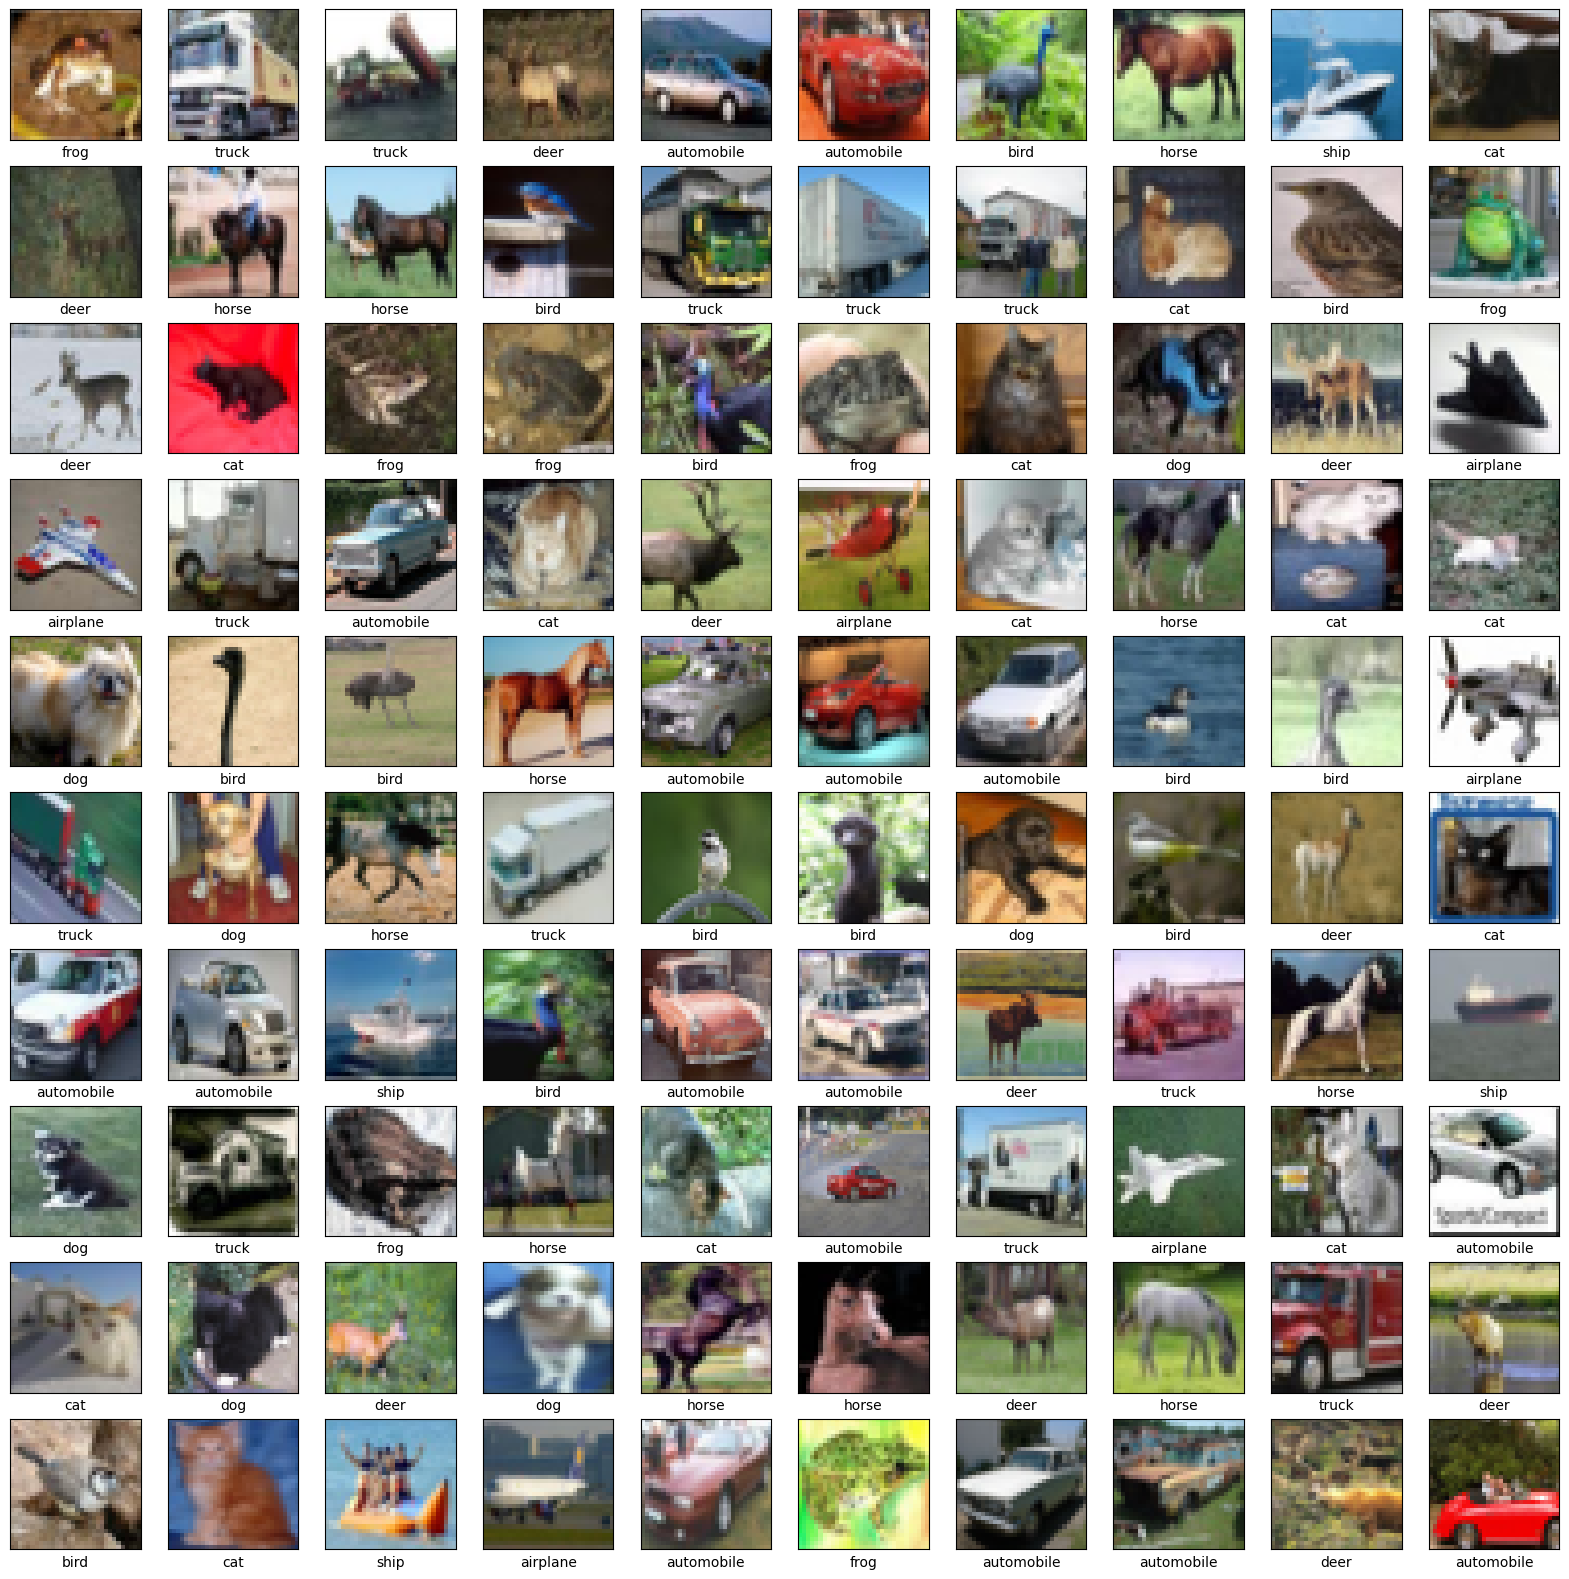

In [5]:
plt.figure(figsize=[20, 20])
for i in range (100):
  plt.subplot(10, 10, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(train_images[i], cmap=plt.cm.binary)
  plt.xlabel(classes[train_labels[i][0]])

plt.show()

<div class="alert alert-danger" role="alert"> 
🔎 Normalize on features

In [6]:
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

In [7]:
print(f"shape of training features is : {train_images.shape}")
print(f"shape of testing features is : {test_images.shape}")

shape of training features is : (50000, 32, 32, 3)
shape of testing features is : (10000, 32, 32, 3)


<div class="alert alert-danger" role="alert"> 
🔎 one-hot on labels

In [8]:
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

<div class="alert alert-danger" role="alert"> 
🔎 Data augmentation

In [9]:
Data_Augment = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False
)

In [10]:
aug_data = Data_Augment.flow(train_images, train_labels, batch_size=train_images.shape[0], shuffle=False)
train_images_aug, train_labels_aug = next(aug_data)

<div class="alert alert-danger" role="alert"> 
🔎 concate artificial and real training data together

In [11]:
augmented_training_image = np.concatenate((train_images, train_images_aug))
augmented_training_labels = np.concatenate((train_labels, train_labels_aug))

In [12]:
augmented_training_image.shape

(100000, 32, 32, 3)

In [13]:
augmented_training_labels.shape

(100000, 10)

<div class="alert alert-danger" role="alert"> 
🔎 build model

In [14]:
output_n = 10

epochs_1 = 10
epochs_2 = 20
batch_size = 64

In [15]:
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.5),


    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(output_n, activation='softmax')
])

In [16]:
model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
history_1 = model_1.fit(augmented_training_image, augmented_training_labels,
                    epochs=epochs_1, batch_size=batch_size, validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 [==============================] - 254s 158ms/step - loss: 1.5068 - accuracy: 0.4707 - val_loss: 1.0878 - val_accuracy: 0.6164
Epoch 2/10
1563/1563 [==============================] - 265s 170ms/step - loss: 1.0801 - accuracy: 0.6231 - val_loss: 0.8922 - val_accuracy: 0.6846
Epoch 3/10
1563/1563 [==============================] - 262s 168ms/step - loss: 0.9556 - accuracy: 0.6683 - val_loss: 0.8438 - val_accuracy: 0.6974
Epoch 4/10
1563/1563 [==============================] - 300s 192ms/step - loss: 0.8764 - accuracy: 0.6973 - val_loss: 0.7695 - val_accuracy: 0.7287
Epoch 5/10
1563/1563 [==============================] - 472s 302ms/step - loss: 0.8225 - accuracy: 0.7193 - val_loss: 0.6902 - val_accuracy: 0.7625
Epoch 6/10
1563/1563 [==============================] - 434s 278ms/step - loss: 0.7811 - accuracy: 0.7314 - val_loss: 0.6981 - val_accuracy: 0.7560
Epoch 7/10
1563/1563 [==============================] - 389s 249ms/step - loss: 0.7483 - accuracy: 0.7431 - val_

In [18]:
model_2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='elu', input_shape=(32, 32, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3, 3), activation='elu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(64, (3, 3), activation='elu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='elu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.5),


    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='elu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(output_n, activation='softmax')
])

In [19]:
model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=5, min_lr=0.0001)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

In [21]:
history_2 = model_2.fit(augmented_training_image, augmented_training_labels, epochs=epochs_2, validation_split=0.2, batch_size=batch_size, shuffle=True, callbacks=[reduce_lr, early_stopping])

Epoch 1/20
1250/1250 [==============================] - 328s 261ms/step - loss: 1.5470 - accuracy: 0.4636 - val_loss: 1.1811 - val_accuracy: 0.5835 - lr: 0.0010
Epoch 2/20
1250/1250 [==============================] - 320s 256ms/step - loss: 1.1259 - accuracy: 0.6130 - val_loss: 1.1113 - val_accuracy: 0.6169 - lr: 0.0010
Epoch 3/20
1250/1250 [==============================] - 330s 264ms/step - loss: 0.9958 - accuracy: 0.6624 - val_loss: 1.1484 - val_accuracy: 0.6142 - lr: 0.0010
Epoch 4/20
1250/1250 [==============================] - 332s 266ms/step - loss: 0.9270 - accuracy: 0.6897 - val_loss: 0.9056 - val_accuracy: 0.6894 - lr: 0.0010
Epoch 5/20
1250/1250 [==============================] - 324s 259ms/step - loss: 0.8746 - accuracy: 0.7119 - val_loss: 0.8171 - val_accuracy: 0.7242 - lr: 0.0010
Epoch 6/20
1250/1250 [==============================] - 323s 259ms/step - loss: 0.8337 - accuracy: 0.7292 - val_loss: 0.7968 - val_accuracy: 0.7344 - lr: 0.0010
Epoch 7/20
1250/1250 [============

<div class="alert alert-danger" role="alert"> 
⬛⬜⬛⬜⬛⬜ Plot

In [22]:
results = {
    'model_1':history_1.history,
    'model_2':history_2.history
}

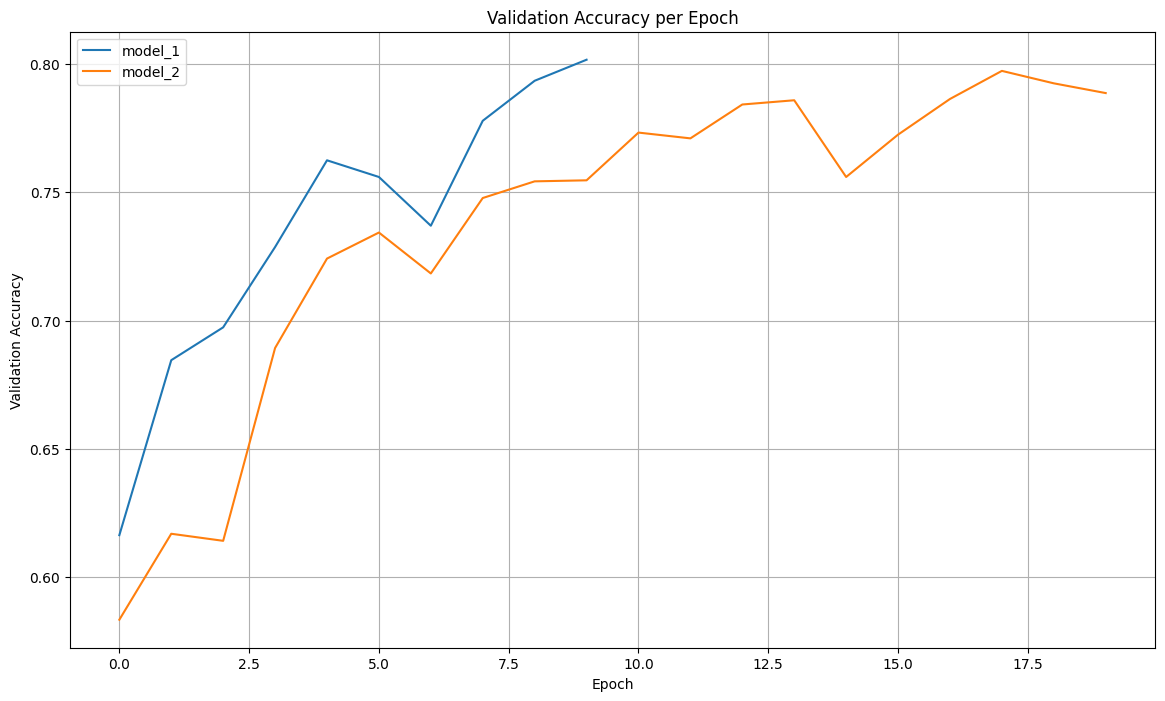

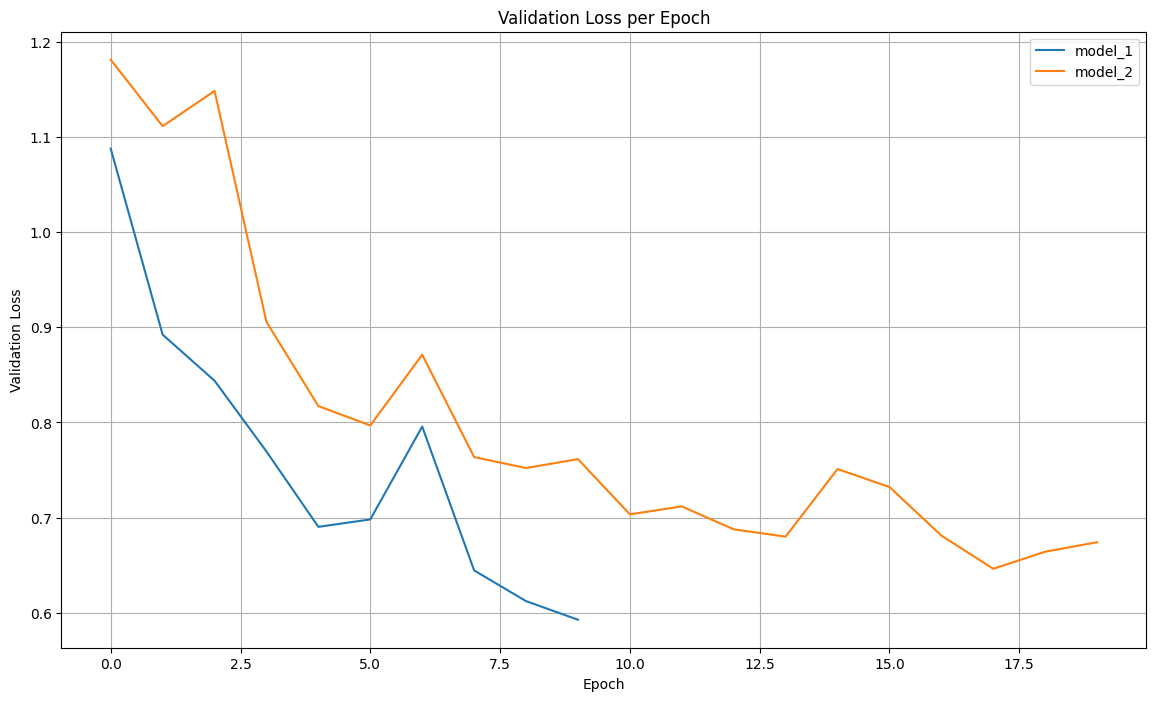

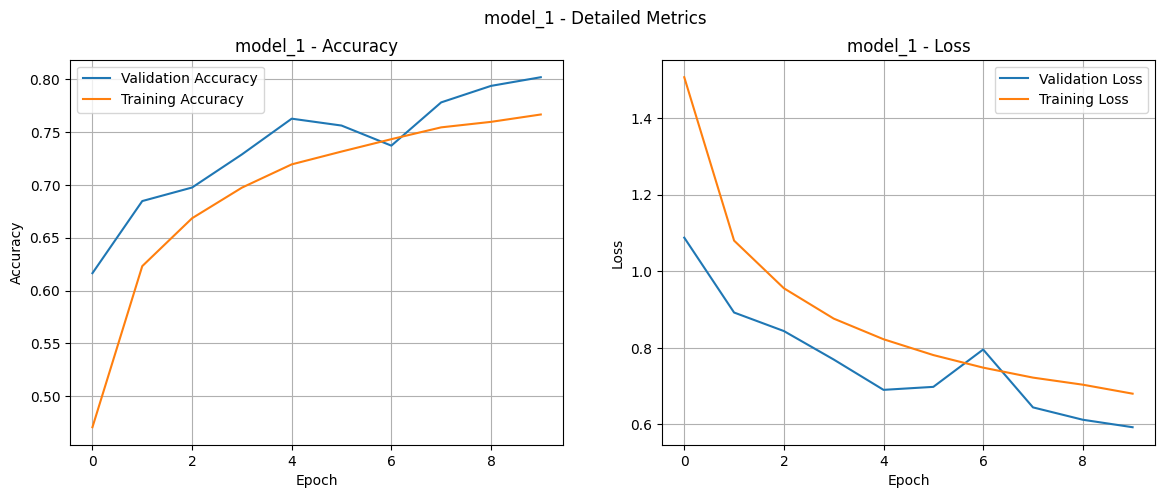

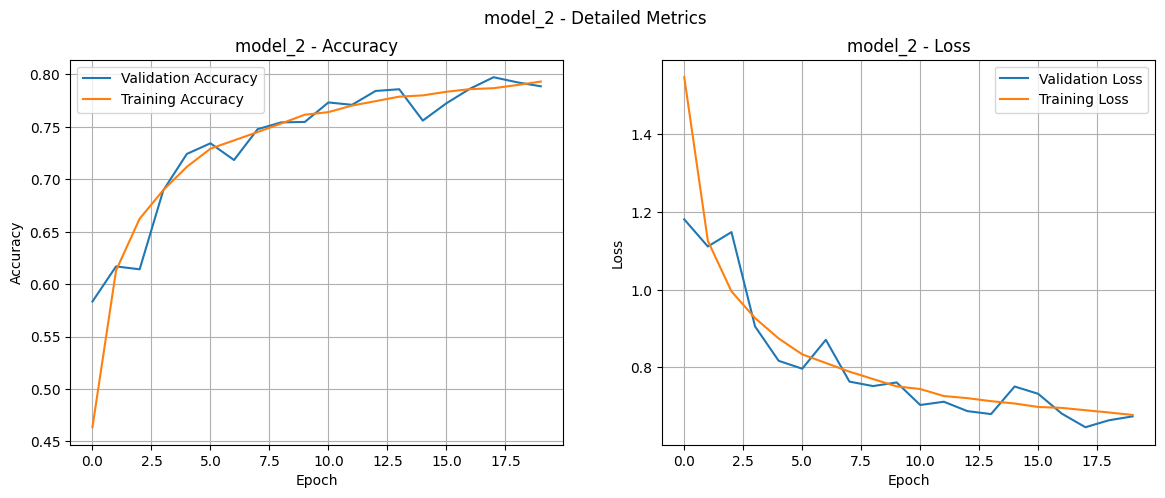

In [23]:
# Plot accuracy for each model
plt.figure(figsize=(14, 8))
for key in results.keys():
    plt.plot(results[key]['val_accuracy'], label=key)
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss for each model
plt.figure(figsize=(14, 8))
for key in results.keys():
    plt.plot(results[key]['val_loss'], label=key)
plt.title('Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot detailed accuracy and loss for each model
for key in results.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(results[key]['val_accuracy'], label='Validation Accuracy')
    ax1.plot(results[key]['accuracy'], label='Training Accuracy')
    ax1.set_title(f'{key} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(results[key]['val_loss'], label='Validation Loss')
    ax2.plot(results[key]['loss'], label='Training Loss')
    ax2.set_title(f'{key} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.suptitle(f'{key} - Detailed Metrics')
    plt.show()

<div class="alert alert-danger" role="alert"> 
🔎 evaluate the model

In [24]:
prediction_1 = model_1.predict(test_images)
prediction_2 = model_2.predict(test_images)

313/313 [==============================] - 6s 18ms/step


In [25]:
test_loss1, test_accuracy1 = model_1.evaluate(test_images, test_labels)
test_loss2, test_accuracy2 = model_2.evaluate(test_images, test_labels)

313/313 [==============================] - 8s 24ms/step - loss: 0.6135 - accuracy: 0.8138


In [26]:
print(f"test loss of model_1 is : {test_loss1} and the test accuracy of model_1 is : {test_accuracy1}")
print(f"test loss of model_2 is : {test_loss2} and the test accuracy of model_2 is : {test_accuracy2}")

test loss of model_1 is : 0.5926529765129089 and the test accuracy of model_1 is : 0.8016999959945679
test loss of model_2 is : 0.61354660987854 and the test accuracy of model_2 is : 0.8137999773025513


In [27]:
test1_arg=np.argmax(test_labels,axis=1)
predict1 = np.argmax(model_1.predict(test_images),axis=1)
print(classification_report(y_true=test1_arg, y_pred=predict1))

313/313 [==============================] - 5s 17ms/step
              precision    recall  f1-score   support

           0       0.79      0.84      0.82      1000
           1       0.87      0.94      0.90      1000
           2       0.70      0.70      0.70      1000
           3       0.76      0.53      0.63      1000
           4       0.84      0.72      0.78      1000
           5       0.71      0.78      0.75      1000
           6       0.71      0.92      0.80      1000
           7       0.90      0.81      0.85      1000
           8       0.91      0.87      0.89      1000
           9       0.86      0.89      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000



In [28]:
test2_arg=np.argmax(test_labels,axis=1)
predict2 = np.argmax(model_2.predict(test_images),axis=1)
print(classification_report(y_true=test2_arg, y_pred=predict2))

313/313 [==============================] - 7s 22ms/step
              precision    recall  f1-score   support

           0       0.88      0.73      0.80      1000
           1       0.95      0.86      0.90      1000
           2       0.84      0.60      0.70      1000
           3       0.71      0.64      0.67      1000
           4       0.82      0.79      0.81      1000
           5       0.73      0.80      0.77      1000
           6       0.75      0.94      0.83      1000
           7       0.82      0.91      0.86      1000
           8       0.87      0.92      0.90      1000
           9       0.80      0.95      0.87      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



In [29]:
# Armin Amani